# Library Imports
**Explanation**: Loading essential Python libraries for data manipulation, numerical computing, and statistical visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Acquisition
**Explanation**: Utilizing kagglehub to securely download the latest clinical diabetes indicators dataset to the local environment.

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/diabetes-health-indicators-dataset")

print("Path to dataset files:", path)


Path to dataset files: /Users/mayankpillai/.cache/kagglehub/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/versions/1


# Data Loading
**Explanation**: Reading the structured CSV dataset into a Pandas DataFrame to facilitate exploratory analysis and preprocessing.

In [12]:
df=pd.read_csv(f'{path}/diabetes_dataset.csv')
df

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0


# Feature Cardinality Analysis
**Explanation**: Evaluating the uniqueness of values in each column to differentiate between continuous indicators and categorical classes.

In [13]:
df.nunique()

age                                     73
gender                                   3
ethnicity                                5
education_level                          4
income_level                             5
employment_status                        4
smoking_status                           3
alcohol_consumption_per_week            11
physical_activity_minutes_per_week     620
diet_score                             101
sleep_hours_per_day                     71
screen_time_hours_per_day              156
family_history_diabetes                  2
hypertension_history                     2
cardiovascular_history                   2
bmi                                    240
waist_to_hip_ratio                      40
systolic_bp                             86
diastolic_bp                            60
heart_rate                              64
cholesterol_total                      210
hdl_cholesterol                         79
ldl_cholesterol                        190
triglycerid

# Initial Data Inspection
**Explanation**: Reviewing the first few records of the dataset to confirm historical data integrity and column alignment.

In [ ]:
df.head()

# Missing Value Audit
**Explanation**: Systematically checking for null entries across all features to ensure the completeness of the clinical record.

In [ ]:
df.isnull().sum()

# Duplicate Record Detection
**Explanation**: Scanning for identical data entries to prevent sample bias and maintain the independence of observations.

In [ ]:
df.duplicated().sum()

# Dataset Dimensionality
**Explanation**: Verifying the total scale of the project, currently consisting of 100,000 patient records and 31 health features.

In [ ]:
df.shape

# Descriptive Statistical Summary
**Explanation**: Computing central tendency and dispersion metrics (mean, std, quartiles) for all numerical health indicators.

In [ ]:
df.describe(include='all')

# Dataset Metadata Inspection
**Explanation**: Analyzing data types and memory allocation to ensure efficient computational processing of the large-scale data.

In [ ]:
df.info()

# Outlier Identification
**Explanation**: Employing boxplots to visually detect statistical outliers and potentially erroneous entries in clinical measurements.

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
palette = sns.color_palette("husl", len(numerical_cols))
plt.figure(figsize=(25, 18))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(6, 6, i)
    sns.boxplot(y=df[col], color=palette[i-1])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Feature Distribution Analysis
**Explanation**: Creating histograms with Kernel Density Estimates to understand the spread and normality of health metrics.

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
plt.figure(figsize=(25, 15))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(6, 6, i)
    sns.histplot(df[col], kde=True, color=palette[i-1], bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


# Categorical Proportion Analysis
**Explanation**: Using pie charts to determine the relative representation of different demographic and diagnostic groups.

In [ ]:
plt.tight_layout()
plt.show()
if len(categorical_cols) > 0:
    plt.figure(figsize=(18, 12))
    for i, col in enumerate(categorical_cols, 1):
        plt.subplot(3, 3, i)
        df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='tab20')
        plt.title(f'Pie Chart of {col}')
        plt.ylabel('')
    plt.tight_layout()
    plt.show()

# Target Variable Correlation
**Explanation**: Visualizing the baseline relationship between categorical predictors and the final diabetic diagnosis.

In [ ]:
plt.tight_layout()
plt.show()
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue="diagnosed_diabetes", palette="viridis")
    plt.title(f"{col} vs diagnosed_diabetes", fontsize=14, color="w")
    plt.xticks(rotation=45)
    plt.show()

# Feature Selection and Noise Reduction
**Explanation**: Pruning irrelevant demographic variables to focus the model on high-impact clinical and lifestyle features.

In [14]:
df=df.drop(columns=['ethnicity','education_level','employment_status','income_level'])

# Categorical Data Encoding
**Explanation**: Converting textual categorical features into numerical formats suitable for mathematical machine learning models.

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [16]:
features = df.drop(['diabetes_stage'], axis=1)

# Training and Validation Split
**Explanation**: Dividing the processed data into training and testing sets to evaluate model performance on unseen data.

In [17]:
from sklearn.model_selection import train_test_split
X = features.iloc[:, :-2]
y = features.iloc[:, -2:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train.head()

,diabetes_risk_score,diagnosed_diabetes
75220,29.9,0
48955,25.8,0
44966,26.6,1
13568,21.3,0
92727,35.4,0


In [18]:
y_tr_r = y_train['diabetes_risk_score']
y_ts_r = y_test['diabetes_risk_score']

# Feature Standardization
**Explanation**: Applying Z-score normalization to ensure all clinical features occupy a uniform scale for the gradient-based regressor.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_tr_s = scaler.transform(X_train)
X_ts_s = scaler.transform(X_test)

print("Features standardized successfully.")

Features standardized successfully.


# Risk Score Prediction - Linear Regression
**Explanation**: Implementing a regression model to estimate a continuous diabetes risk score based on scaled clinical inputs.

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_tr_s, y_tr_r)

y_pred_risk_score = lr.predict(X_ts_s)
y_pred_risk_score = np.clip(y_pred_risk_score, 0, 100)

print("Linear Regression model trained and predictions made.")

Linear Regression model trained and predictions made.


# Regression Performance Metrics
**Explanation**: Quantifying the accuracy of the risk score prediction using R-squared, Mean Squared Error, and Mean Absolute Error.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Evaluate the Linear Regression model
r2 = r2_score(y_ts_r, y_pred_risk_score)
mse = mean_squared_error(y_ts_r, y_pred_risk_score)
mae = mean_absolute_error(y_ts_r, y_pred_risk_score)

print(f"Linear Regression - Diabetes Risk Score Prediction")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

Linear Regression - Diabetes Risk Score Prediction
R-squared: 0.9933
Mean Squared Error: 0.5544
Mean Absolute Error: 0.4391


# Cross-Validation Analysis
**Explanation**: Performing K-Fold cross-validation to ensure the risk prediction logic is robust and not overfitted to specific samples.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

lr_cv = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(lr_cv, X_tr_s, y_tr_r, cv=kf, scoring='r2')
print(f"Cross-validated R-squared: {r2_cv.mean():.4f} (+/- {r2_cv.std():.4f})")

# Perform cross-validation for Mean Squared Error (negated because cross_val_score minimizes by default)
mse_cv = -cross_val_score(lr_cv, X_tr_s, y_tr_r, cv=kf, scoring='neg_mean_squared_error')
print(f"Cross-validated Mean Squared Error: {mse_cv.mean():.4f} (+/- {mse_cv.std():.4f})")

# Perform cross-validation for Mean Absolute Error (negated)
mae_cv = -cross_val_score(lr_cv, X_tr_s, y_tr_r, cv=kf, scoring='neg_mean_absolute_error')
print(f"Cross-validated Mean Absolute Error: {mae_cv.mean():.4f} (+/- {mae_cv.std():.4f})")

Cross-validated R-squared: 0.9935 (+/- 0.0002)
Cross-validated Mean Squared Error: 0.5297 (+/- 0.0203)
Cross-validated Mean Absolute Error: 0.4326 (+/- 0.0032)


In [ ]:
y_pred_tr_r = lr.predict(X_tr_s)
y_pred_tr_r = np.clip(y_pred_tr_r, 0, 100)

print("Predicted risk scores for training data generated successfully.")

Predicted risk scores for training data generated successfully.


# Integrated Feature Engineering
**Explanation**: Synthesizing original clinical features with predicted risk scores to provide a multi-dimensional input for the classifier.

In [24]:
X_tr_s_df = pd.DataFrame(X_tr_s, columns=X_train.columns, index=X_train.index)
X_ts_s_df = pd.DataFrame(X_ts_s, columns=X_test.columns, index=X_test.index)

X_tr_c = X_tr_s_df.copy()
X_tr_c['pred_r'] = y_pred_tr_r

X_ts_c = X_ts_s_df.copy()
X_ts_c['pred_r'] = y_pred_r

print("Combined feature sets (X_tr_c and X_ts_c) created successfully with predicted risk scores.")

Combined feature sets (X_train_combined and X_test_combined) created successfully with predicted risk scores.


In [25]:
y_tr_d = y_train['diagnosed_diabetes']
y_ts_d = y_test['diagnosed_diabetes']

print("Extracted 'diagnosed_diabetes' for training and testing target variables.")

Extracted 'diagnosed_diabetes' for training and testing target variables.


# Decision Tree Classifier - Primary Training
**Explanation**: Developing a Decision Tree model to classify patients into Diabetic or Non-Diabetic categories based on integrated data.

In [26]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_tr_c, y_tr_d)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


# Classification Performance Evaluation
**Explanation**: Measuring diagnostic precision through Accuracy, Recall, and F1-Score to determine clinical reliability.

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred_diagnosed = dtc.predict(X_ts_c)

accuracy = accuracy_score(y_ts_d, y_pred_diagnosed)
precision = precision_score(y_ts_d, y_pred_diagnosed)
recall = recall_score(y_ts_d, y_pred_diagnosed)
f1 = f1_score(y_ts_d, y_pred_diagnosed)
report = classification_report(y_ts_d, y_pred_diagnosed)

print(f"Decision Tree Classifier Performance (with predicted risk score as feature):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:\n", report)

Decision Tree Classifier Performance (with predicted risk score as feature):
Accuracy: 0.8638
Precision: 0.8796
Recall: 0.8938
F1-Score: 0.8866

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.82      0.83      8077
           1       0.88      0.89      0.89     11923

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



# Hyperparameter Space Definition
**Explanation**: Establishing the configuration grid for fine-tuning the Decision Tree properties such as depth and leaf requirements.

In [28]:
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

print("Hyperparameter grid 'param_grid' defined successfully.")

Hyperparameter grid 'param_grid' defined successfully.


# Automated Hyperparameter Optimization
**Explanation**: Conducting a grid search to automatically identify the most accurate structural settings for the classification tree.

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier

kf_grid = KFold(n_splits=5, shuffle=True, random_state=42)

dtc_grid = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dtc_grid,
    param_grid=param_grid,
    cv=kf_grid,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV initialized successfully.")

GridSearchCV initialized successfully.


In [30]:
grid_search.fit(X_tr_c, y_tr_d)

print("GridSearchCV fitting complete.")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
GridSearchCV fitting complete.


# Optimal Configuration Identification
**Explanation**: Identifying the precise set of hyperparameters that yielded the highest weighted F1-Score during cross-validation.

In [31]:
print("Best parameters found by GridSearchCV:", grid_search.best_params_)
print("Best F1-weighted score:", grid_search.best_score_)

Best parameters found by GridSearchCV: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best F1-weighted score: 0.920642202734389


# Final Optimized Classifier Generation
**Explanation**: Producing the fine-tuned, high-performance Decision Tree model for finalized diabetic status prediction.

In [32]:
dt_best = grid_search.best_estimator_

print("Best Decision Tree Classifier obtained from GridSearchCV.")

Best Decision Tree Classifier obtained from GridSearchCV.


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred_dt_best = dt_best.predict(X_ts_c)

accuracy_best = accuracy_score(y_ts_d, y_pred_dt_best)
precision_best = precision_score(y_ts_d, y_pred_dt_best)
recall_best = recall_score(y_ts_d, y_pred_dt_best)
f1_best = f1_score(y_ts_d, y_pred_dt_best)
report_best = classification_report(y_ts_d, y_pred_dt_best)

print(f"Best Decision Tree Classifier Performance (tuned with GridSearchCV):")
print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")
print("\nClassification Report:\n", report_best)

Best Decision Tree Classifier Performance (tuned with GridSearchCV):
Accuracy: 0.9194
Precision: 0.9980
Recall: 0.8666
F1-Score: 0.9276

Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      8077
           1       1.00      0.87      0.93     11923

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



# Diagnostic Accuracy Heatmap
**Explanation**: Visualizing the distribution of True Positives and False Positives via a normalized confusion matrix.

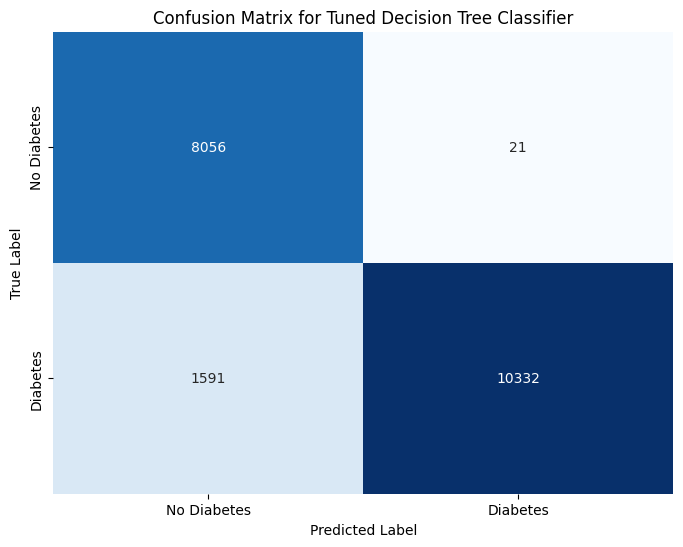

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_ts_d, y_pred_dt_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned Decision Tree Classifier')
plt.show()

# Model and Scaler Persistence
**Explanation**: Serializing the final models and the standardization scaler into a single file for seamless deployment in the Streamlit app.

In [35]:
import pickle

all_models = {
    'lr': lr,
    'dt': dt_best,
    'scaler': scaler
}

combined_model_filename = 'diabetes_prediction_models.pkl'

with open(combined_model_filename, 'wb') as file:
    pickle.dump(all_models, file)

print(f"Both models and scaler successfully re-saved to {combined_model_filename}")

Both models and scaler successfully re-saved to diabetes_prediction_models.pkl
